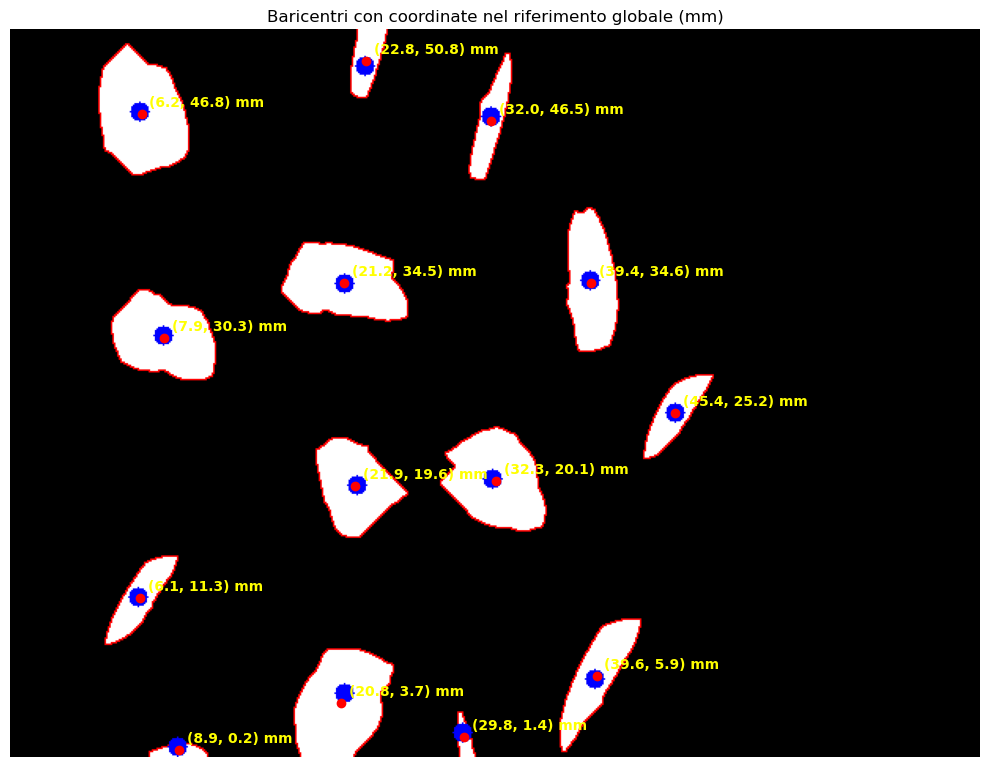

In [1]:
#%%
import numpy as np
import cv2
import tkinter as tk
from tkinter import filedialog
import matplotlib.pyplot as plt
import os

# === Definizione omografia manuale ===
# Punti nel mondo (mm)
p_1_w = np.array([21, 14])
p_2_w = np.array([56, 14])
p_3_w = np.array([63, 35])
p_4_w = np.array([28, 28])

# Punti immagine (pixel)
p_1_i = np.array([211, 338])
p_2_i = np.array([514, 341])
p_3_i = np.array([573, 159])
p_4_i = np.array([271, 217])

world_points = np.array([p_1_w, p_2_w, p_3_w, p_4_w], dtype=np.float64)
image_points = np.array([p_1_i, p_2_i, p_3_i, p_4_i], dtype=np.float64)

def compute_homography(world_pts, image_pts):
    A = []
    for i in range(len(world_pts)):
        X, Y = world_pts[i]
        x, y = image_pts[i]
        A.append([-X, -Y, -1, 0, 0, 0, x*X, x*Y, x])
        A.append([0, 0, 0, -X, -Y, -1, y*X, y*Y, y])
    A = np.array(A)
    _, _, Vt = np.linalg.svd(A)
    H = Vt[-1].reshape(3, 3)
    return H / H[2, 2]

def image_to_world(H, img_pts):
    H_inv = np.linalg.inv(H)
    world_pts = []
    for pt in img_pts:
        img_coord = np.array([pt[0], pt[1], 1.0])
        world_coord = H_inv @ img_coord
        world_coord /= world_coord[2]
        world_pts.append(world_coord[:2])
    return np.array(world_pts)

# Calcolo omografia
H = compute_homography(world_points, image_points)

# === GUI per selezione file immagine ===
root = tk.Tk()
root.withdraw()  # Nasconde la finestra principale
file_path = filedialog.askopenfilename(title="Seleziona l'immagine con i baricentri")

if not file_path:
    raise Exception("Nessuna immagine selezionata.")

# === Elaborazione immagine ===
image = cv2.imread(file_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)

# Etichettatura componenti connesse
num_labels, labels = cv2.connectedComponents(binary)

# Estrazione baricentri
centroids = []
for label in range(1, num_labels):  # salta lo sfondo
    coords = np.column_stack(np.where(labels == label))
    if coords.size == 0:
        continue
    centroid = np.mean(coords, axis=0)  # (y, x)
    centroids.append((centroid[1], centroid[0]))  # salva come (x, y)

centroids = np.array(centroids)
centroids_world = image_to_world(H, centroids)

# === Visualizzazione con baricentri e coordinate globali ===
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(image_rgb)
for i, (pt_img, pt_w) in enumerate(zip(centroids, centroids_world)):
    x, y = pt_img
    Xw, Yw = pt_w
    ax.plot(x, y, 'ro')
    ax.text(x + 5, y - 5, f"({Xw:.1f}, {Yw:.1f}) mm", color='yellow', fontsize=10, weight='bold')

ax.set_title("Baricentri con coordinate nel riferimento globale (mm)")
ax.axis('off')
plt.tight_layout()
plt.show()
